In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os
from datetime import date

print("Libraries loaded successfully")


Libraries loaded successfully


In [ ]:

TICKER     = "OGDC.KA"   # PSX ticker — .KA means Pakistan
NAME       = "OGDC"       # short name for saving files
START_DATE = "2023-01-01" # from when
END_DATE   = date.today().strftime("%Y-%m-%d") # till today

print(f"Stock      : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")

Stock      : OGDC.KA
Start date : 2023-01-01
End date   : 2026-08-02


In [ ]:
print(f"Fetching data for {TICKER}...")

df = yf.download(TICKER, start=START_DATE, end=END_DATE)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

print(f"\nData fetched successfully!")
print(f"Total trading days : {len(df)}")
print(f"From               : {df.index[0].date()}")
print(f"To                 : {df.index[-1].date()}")
print(f"Columns            : {df.columns.tolist()}")

Fetching data for OGDC.KA...


[*********************100%***********************]  1 of 1 completed


Data fetched successfully!
Total trading days : 914
From               : 2023-01-02
To                 : 2026-07-30
Columns            : ['Close', 'High', 'Low', 'Open', 'Volume']


In [5]:
print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== BASIC INFO ===")
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe().round(2))

=== FIRST 5 ROWS ===
Price           Close       High        Low       Open   Volume
Date                                                           
2023-01-02  61.928005  63.803910  60.993914  61.063389  7749060
2023-01-03  61.711853  62.452950  61.387618  62.144158  1858912
2023-01-04  60.638813  62.452958  60.445819  61.819937  2277612
2023-01-05  61.580612  62.144158  60.908996  60.986192  3589864
2023-01-06  63.541447  64.074113  61.294996  61.758181  6016343

=== BASIC INFO ===
Shape   : (914, 5)
Columns : ['Close', 'High', 'Low', 'Open', 'Volume']

=== MISSING VALUES ===
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

=== BASIC STATISTICS ===
Price   Close    High     Low    Open       Volume
count  914.00  914.00  914.00  914.00       914.00
mean   168.38  170.93  166.19  168.60   6836093.18
std     86.22   87.26   85.27   86.34   6276044.91
min     57.24   59.32   56.48   57.51         0.00
25%     90.36   91.61   88.04   88.44   3006559.50
50% 

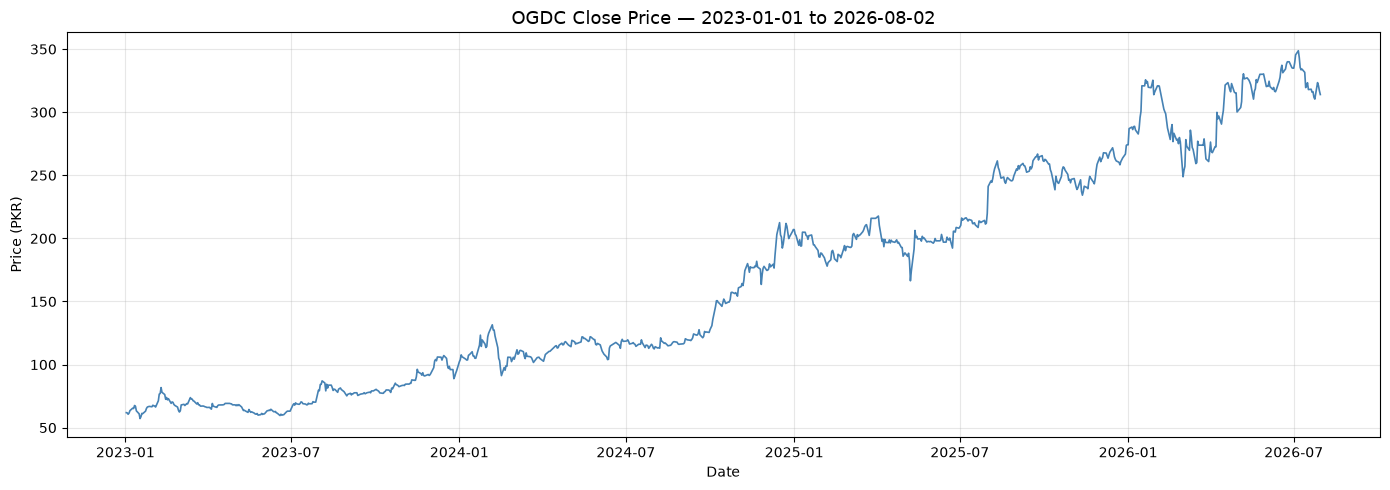

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df['Close'],
         color='steelblue',
         linewidth=1.2)

plt.title(f'{NAME} Close Price — '
          f'{START_DATE} to {END_DATE}',
          fontsize=13)
plt.xlabel('Date')
plt.ylabel('Price (PKR)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

os.makedirs('../data', exist_ok=True)

# Save
file_path = f'../data/{NAME}_raw.csv'
df.to_csv(file_path)

print(f"Saved successfully!")
print(f"File     : {file_path}")
print(f"Rows     : {len(df)}")
print(f"Columns  : {df.columns.tolist()}")

Saved successfully!
File     : ../data/OGDC_raw.csv
Rows     : 914
Columns  : ['Close', 'High', 'Low', 'Open', 'Volume']


In [8]:
df_check = pd.read_csv(f'../data/{NAME}_raw.csv',
                        index_col='Date',
                        parse_dates=True)

print("=== VERIFICATION ===")
print(f"Shape      : {df_check.shape}")
print(f"First date : {df_check.index[0].date()}")
print(f"Last date  : {df_check.index[-1].date()}")
print(f"Missing    : {df_check.isnull().sum().sum()}")
print(f"\nFirst 3 rows:")
print(df_check.head(3))
print("\n✓ Phase 1 Complete!")

=== VERIFICATION ===
Shape      : (914, 5)
First date : 2023-01-02
Last date  : 2026-07-30
Missing    : 0

First 3 rows:
                Close       High        Low       Open   Volume
Date                                                           
2023-01-02  61.928005  63.803910  60.993914  61.063389  7749060
2023-01-03  61.711853  62.452950  61.387618  62.144158  1858912
2023-01-04  60.638813  62.452958  60.445819  61.819937  2277612

✓ Phase 1 Complete!
